In [ ]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

[Learn the Basics](intro.html) \|\| **Quickstart** \|\|
[Tensors](tensorqs_tutorial.html) \|\| [Datasets &
DataLoaders](data_tutorial.html) \|\|
[Transforms](transforms_tutorial.html) \|\| [Build
Model](buildmodel_tutorial.html) \|\|
[Autograd](autogradqs_tutorial.html) \|\|
[Optimization](optimization_tutorial.html) \|\| [Save & Load
Model](saveloadrun_tutorial.html)

Quickstart
==========

This section runs through the API for common tasks in machine learning.
Refer to the links in each section to dive deeper.

Working with data
-----------------

PyTorch has two [primitives to work with
data](https://pytorch.org/docs/stable/data.html):
`torch.utils.data.DataLoader` and `torch.utils.data.Dataset`. `Dataset`
stores the samples and their corresponding labels, and `DataLoader`
wraps an iterable around the `Dataset`.


In [67]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

PyTorch offers domain-specific libraries such as
[TorchText](https://pytorch.org/text/stable/index.html),
[TorchVision](https://pytorch.org/vision/stable/index.html), and
[TorchAudio](https://pytorch.org/audio/stable/index.html), all of which
include datasets. For this tutorial, we will be using a TorchVision
dataset.

The `torchvision.datasets` module contains `Dataset` objects for many
real-world vision data like CIFAR, COCO ([full list
here](https://pytorch.org/vision/stable/datasets.html)). In this
tutorial, we use the FashionMNIST dataset. Every TorchVision `Dataset`
includes two arguments: `transform` and `target_transform` to modify the
samples and labels respectively.


In [68]:
# Download training data from open datasets.
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

We pass the `Dataset` as an argument to `DataLoader`. This wraps an
iterable over our dataset, and supports automatic batching, sampling,
shuffling and multiprocess data loading. Here we define a batch size of
64, i.e. each element in the dataloader iterable will return a batch of
64 features and labels.


In [69]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


Read more about [loading data in PyTorch](data_tutorial.html).


------------------------------------------------------------------------


Creating Models
===============

To define a neural network in PyTorch, we create a class that inherits
from
[nn.Module](https://pytorch.org/docs/stable/generated/torch.nn.Module.html).
We define the layers of the network in the `__init__` function and
specify how data will pass through the network in the `forward`
function. To accelerate operations in the neural network, we move it to
the
[accelerator](https://pytorch.org/docs/stable/torch.html#accelerators)
such as CUDA, MPS, MTIA, or XPU. If the current accelerator is
available, we will use it. Otherwise, we use the CPU.


In [70]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cpu device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Read more about [building neural networks in
PyTorch](buildmodel_tutorial.html).


------------------------------------------------------------------------


Optimizing the Model Parameters
===============================

To train a model, we need a [loss
function](https://pytorch.org/docs/stable/nn.html#loss-functions) and an
[optimizer](https://pytorch.org/docs/stable/optim.html).


In [71]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In a single training loop, the model makes predictions on the training
dataset (fed to it in batches), and backpropagates the prediction error
to adjust the model\'s parameters.


In [72]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

We also check the model\'s performance against the test dataset to
ensure it is learning.


In [73]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

The training process is conducted over several iterations (*epochs*).
During each epoch, the model learns parameters to make better
predictions. We print the model\'s accuracy and loss at each epoch;
we\'d like to see the accuracy increase and the loss decrease with every
epoch.


In [75]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.280975  [   64/60000]
loss: 2.262575  [ 6464/60000]
loss: 2.239845  [12864/60000]
loss: 2.245853  [19264/60000]
loss: 2.222539  [25664/60000]
loss: 2.186475  [32064/60000]
loss: 2.204393  [38464/60000]
loss: 2.156234  [44864/60000]
loss: 2.155562  [51264/60000]
loss: 2.123314  [57664/60000]
Test Error: 
 Accuracy: 54.7%, Avg loss: 2.111028 

Epoch 2
-------------------------------
loss: 2.128567  [   64/60000]
loss: 2.106773  [ 6464/60000]
loss: 2.034203  [12864/60000]
loss: 2.055404  [19264/60000]
loss: 1.997911  [25664/60000]
loss: 1.933172  [32064/60000]
loss: 1.967525  [38464/60000]
loss: 1.873235  [44864/60000]
loss: 1.880770  [51264/60000]
loss: 1.800169  [57664/60000]
Test Error: 
 Accuracy: 60.2%, Avg loss: 1.797894 

Epoch 3
-------------------------------
loss: 1.848869  [   64/60000]
loss: 1.805122  [ 6464/60000]
loss: 1.667873  [12864/60000]
loss: 1.714613  [19264/60000]
loss: 1.611604  [25664/60000]
loss: 1.572995  [32064/600

Read more about [Training your model](optimization_tutorial.html).


Going from 5 to 10 epochs improved accuracy from 63.8% to 70.3% (6.5 points), which is a meaningful gain just from training longer. We observed that the first few epochs the increases in accuracy were quite substantial, however as you increase the number of epochs the increases in accuracy slowly decrease. The pattern appears to be logarithmic, with fast and meaningful gains in the first few epochs, then as you keep training the model the curve flattens out and the gains become less and less.

------------------------------------------------------------------------


Saving Models
=============

A common way to save a model is to serialize the internal state
dictionary (containing the model parameters).


In [76]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


Loading Models
==============

The process for loading a model includes re-creating the model structure
and loading the state dictionary into it.


In [77]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

This model can now be used to make predictions.


In [78]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"


Read more about [Saving & Loading your
model](saveloadrun_tutorial.html).


In [81]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class MyNetwork1(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 768),
            nn.ReLU(),
            nn.Linear(768, 768),
            nn.ReLU(),
            nn.Linear(768, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model_mynetwork1 = MyNetwork1().to(device)
print(model_mynetwork1)

Using cpu device
MyNetwork1(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=768, bias=True)
    (1): ReLU()
    (2): Linear(in_features=768, out_features=768, bias=True)
    (3): ReLU()
    (4): Linear(in_features=768, out_features=10, bias=True)
  )
)


In [82]:
loss_fn = nn.CrossEntropyLoss()
optimizer_mynetwork1 = torch.optim.SGD(model_mynetwork1.parameters(), lr=1e-3)
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_mynetwork1, loss_fn, optimizer_mynetwork1)
    test(test_dataloader, model_mynetwork1, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.299499  [   64/60000]
loss: 2.290046  [ 6464/60000]
loss: 2.265033  [12864/60000]
loss: 2.260976  [19264/60000]
loss: 2.241858  [25664/60000]
loss: 2.211448  [32064/60000]
loss: 2.214666  [38464/60000]
loss: 2.174256  [44864/60000]
loss: 2.171113  [51264/60000]
loss: 2.133744  [57664/60000]
Test Error: 
 Accuracy: 53.0%, Avg loss: 2.126140 

Epoch 2
-------------------------------
loss: 2.138880  [   64/60000]
loss: 2.131043  [ 6464/60000]
loss: 2.056454  [12864/60000]
loss: 2.076250  [19264/60000]
loss: 2.032517  [25664/60000]
loss: 1.966104  [32064/60000]
loss: 1.983672  [38464/60000]
loss: 1.898098  [44864/60000]
loss: 1.898272  [51264/60000]
loss: 1.818693  [57664/60000]
Test Error: 
 Accuracy: 60.6%, Avg loss: 1.816096 

Epoch 3
-------------------------------
loss: 1.854319  [   64/60000]
loss: 1.826475  [ 6464/60000]
loss: 1.682034  [12864/60000]
loss: 1.732142  [19264/60000]
loss: 1.639642  [25664/60000]
loss: 1.585694  [32064/600

The larger network achieved a final accuracy of 72.2% compared to 70.3% for the original — a modest improvement of 1.9 percentage points. The average loss also improved slightly, dropping from 0.786 to 0.774.

The improvement is quite small. A wider hidden layers give the network more parameters and therefore more capacity to learn complex patterns, but the gain is modest because the overall architecture remains the same. Simply making layers wider appears to have diminishing returns on its own.

In [86]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class MyNetwork2(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model_mynetwork2 = MyNetwork2().to(device)
print(model_mynetwork2)

Using cpu device
MyNetwork2(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [87]:
loss_fn = nn.CrossEntropyLoss()
optimizer_mynetwork2 = torch.optim.SGD(model_mynetwork2.parameters(), lr=1e-3)
epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model_mynetwork2, loss_fn, optimizer_mynetwork2)
    test(test_dataloader, model_mynetwork2, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.306116  [   64/60000]
loss: 2.301350  [ 6464/60000]
loss: 2.298967  [12864/60000]
loss: 2.292353  [19264/60000]
loss: 2.297633  [25664/60000]
loss: 2.291448  [32064/60000]
loss: 2.287513  [38464/60000]
loss: 2.286713  [44864/60000]
loss: 2.276778  [51264/60000]
loss: 2.276007  [57664/60000]
Test Error: 
 Accuracy: 33.0%, Avg loss: 2.275851 

Epoch 2
-------------------------------
loss: 2.278773  [   64/60000]
loss: 2.276944  [ 6464/60000]
loss: 2.266132  [12864/60000]
loss: 2.265017  [19264/60000]
loss: 2.267428  [25664/60000]
loss: 2.248766  [32064/60000]
loss: 2.255502  [38464/60000]
loss: 2.243753  [44864/60000]
loss: 2.233142  [51264/60000]
loss: 2.228118  [57664/60000]
Test Error: 
 Accuracy: 38.2%, Avg loss: 2.228472 

Epoch 3
-------------------------------
loss: 2.234369  [   64/60000]
loss: 2.234771  [ 6464/60000]
loss: 2.209807  [12864/60000]
loss: 2.213453  [19264/60000]
loss: 2.211918  [25664/60000]
loss: 2.171286  [32064/600

The deeper network started significantly behind only at 33.0% accuracy at Epoch 1 compared to 54.7% for the original. However it is able to catch up to the originals accuracy at around epoch 14-15. This means that this specific deeper neural network requires around 1.5 times as much training to get the same accuracy as the original single layer neural network.

Another important detail to note: the final accuracy was 75.3% which is larger than the two previous neural networks and the increases in accuracy decreased slower as we increased in epochs compared to the other two networks.

Evidently the deeper neural network is more computationally expensive than teh single layer neural networks. Whether the accuracy gain is worth the extra training time depends on the application. This specific task of classifying grainy images as different articles of clothing doesn't seem very complex. The gains of a single layer network were small but noticable. The increase in accuracy of having multiple layers may vary depending on the task.



=====MyNetwork1=====
Error 1
  Ground Truth: Shirt
  Prediction:   Coat


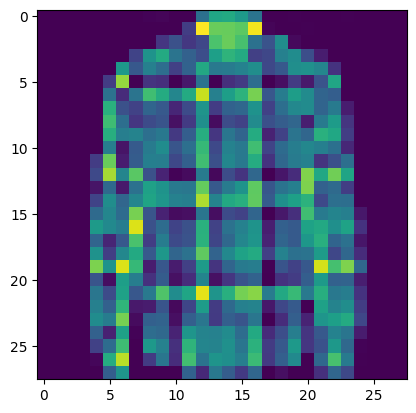

Error 2
  Ground Truth: Sandal
  Prediction:   Sneaker


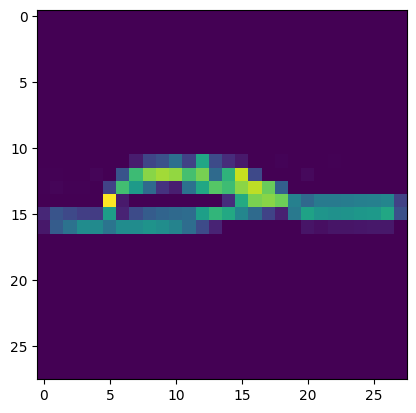

Error 3
  Ground Truth: Coat
  Prediction:   Pullover


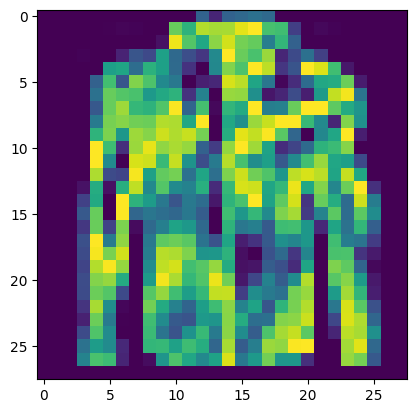

/n=====MyNetwork2=====
Error 1
  Ground Truth: Shirt
  Prediction:   Coat


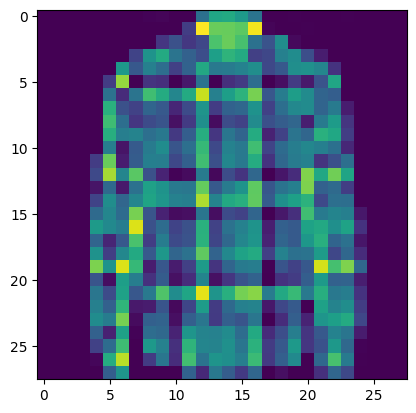

Error 2
  Ground Truth: Sandal
  Prediction:   Sneaker


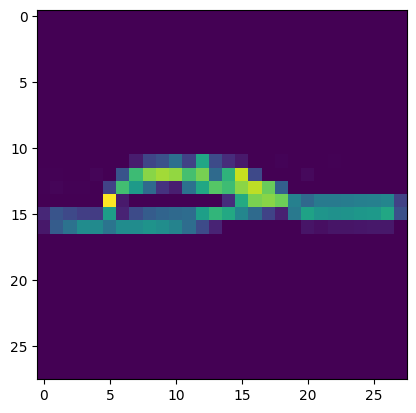

Error 3
  Ground Truth: Coat
  Prediction:   Pullover


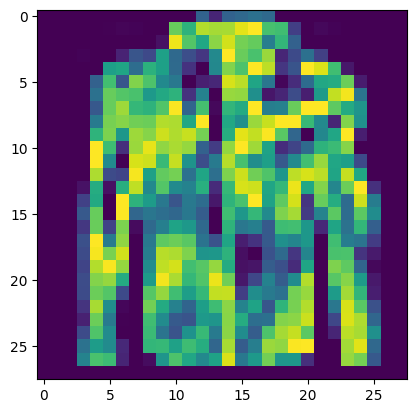

In [88]:
import matplotlib.pyplot as plt

def find_and_display_errors(model, dataloader, num_errors=3):
    class_names = dataloader.dataset.classes  # Pull class names directly from the dataset
    model.eval()
    errors_found = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # Get predictions
            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            # Check each image in the batch for mistakes
            for i in range(len(labels)):
                if predictions[i] != labels[i]:
                    img = images[i]
                    true_label = class_names[labels[i].item()]
                    pred_label = class_names[predictions[i].item()]

                    # Display each misclassified image individually
                    image_np = img.permute(1, 2, 0).cpu().numpy()
                    print(f"Error {errors_found + 1}")
                    print(f"  Ground Truth: {true_label}")
                    print(f"  Prediction:   {pred_label}")
                    plt.imshow(image_np)
                    plt.show()

                    errors_found += 1
                    if errors_found >= num_errors:
                        return  # Stop once we've found enough errors
print("=====MyNetwork1=====")
find_and_display_errors(model_mynetwork1, test_dataloader)
print("/n=====MyNetwork2=====")
find_and_display_errors(model_mynetwork1, test_dataloader)